In [47]:
import sys
sys.path.append("..")
%run "../moduli.py"

Funzione teorica
$$\Delta\phi(\omega) = \arctan(\frac{1}{Q} \frac{1}{(\frac{\Omega}{\omega} - \frac{\omega}{\Omega})})$$

con $ \omega = 2 \pi f$.

In [ ]:
def modello(par, f): # Capi di C
    Omega, Q, x_off, y_off = par
    #omega = 2 * np.pi * (f + x_off)
    omega = f + x_off
    return np.arctan(
        (1 / Q) * (1 / ((Omega / omega) - (omega / Omega)))
    ) + y_off

param_labels = ["\\omega_0", "Q", "f_{off}", "\\Phi_{off}"]

#beta0 = [233*10**4, 3, 1, 1]
beta0 = [2*np.pi*70000, 6, 1, 1]

print(beta0[0])

439822.971502571


In [ ]:
def modello(par, f): # Capi di R
    Omega, Q, x_off, y_off = par
    #omega = 2 * np.pi * (f + x_off)
    omega = f + x_off
    return np.arctan(
        Q * ((Omega / omega) - (omega / Omega))
    ) + y_off

param_labels = ["\\omega_0", "Q", "f_{off}", "\\Phi_{off}"]

#beta0 = [233*10**4, 3, 1, 1]
beta0 = [2*np.pi*70000, 6, 1, 1]

print(beta0[0])

439822.971502571


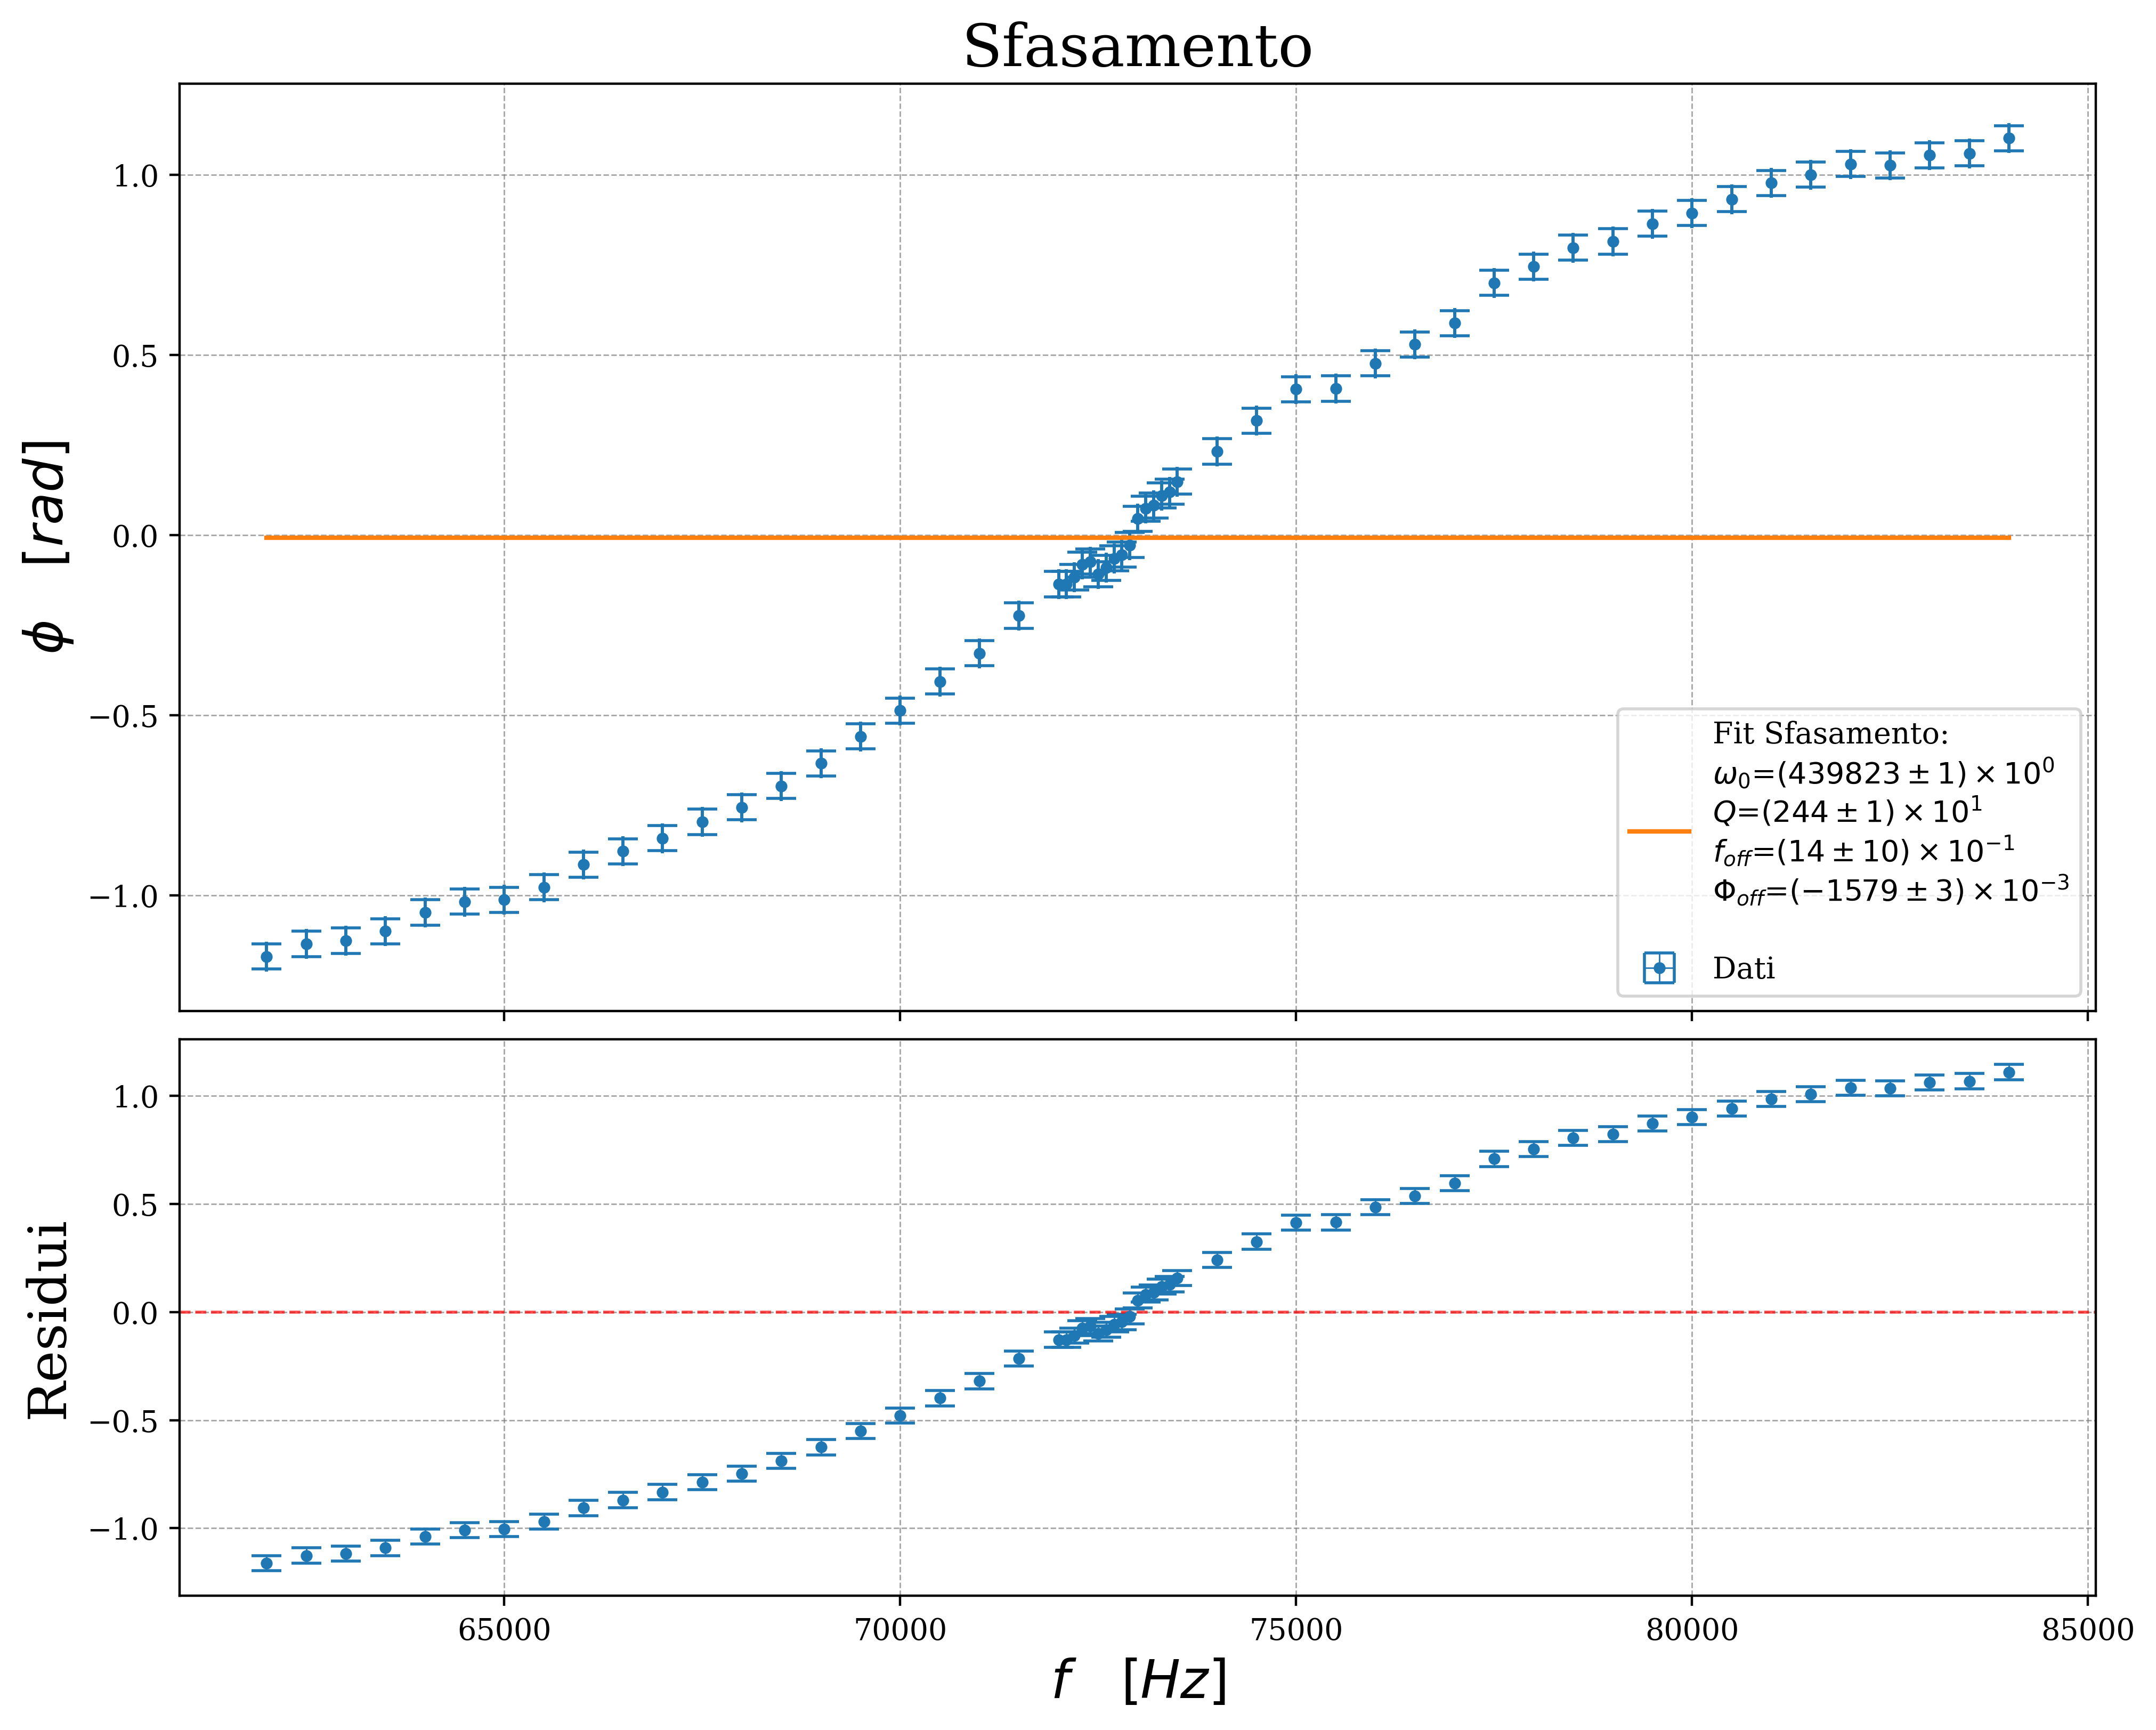

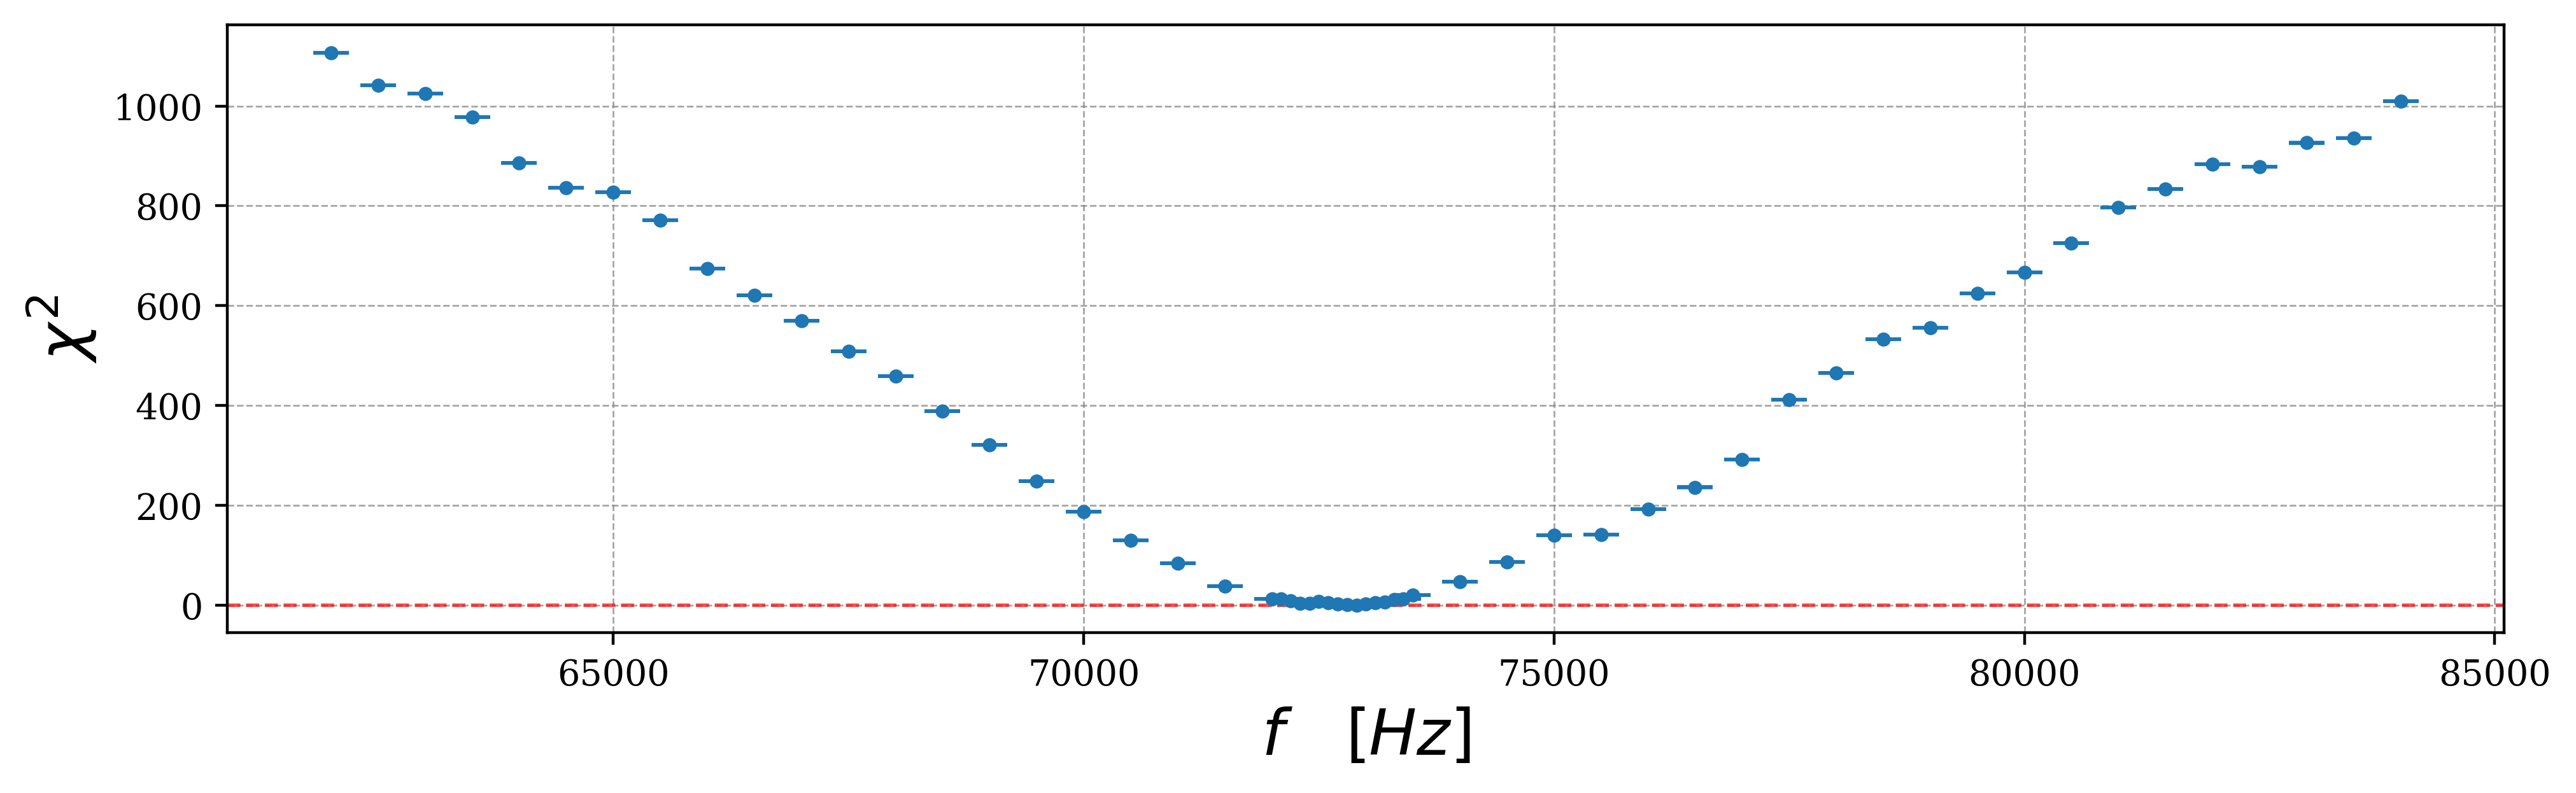

In [50]:
analisi = analizza("sfasamento", modello, param_labels, beta0, legenda_bbox = (1,0), legenda_loc="lower right", legenda_fontsize = 10)

In [51]:
print(analisi)

Parametri regressione :
439823.4728084239 ± 1.0000019393169874
2438.6105581096117 ± 10.001332622195232
1.4215002018429839 ± 0.9968250363182946
-1.5788406081384547 ± 0.0032323539936467377

Somma residui :
0.0000
Somma chi quadri e chi ridotto :
23211.2241
437.9476



In [52]:
par = analisi.anal[0]
spar = analisi.anal[1]

parametri_profilazione = [[par[0], par[1]], [spar[0], spar[1]]]
parametri_offset = [par[2], par[3]]
parametri = [parametri_profilazione, parametri_offset]
let.esporta_pickle(parametri, "sfasamento.pkl")